# Analýza studentského duševního zdraví
## Týmová seminární práce o strojovém učení

**Dataset:** Student Mental Health — OpenML ID 46874  
**Zdroj:** https://www.openml.org/search?type=data&status=active&id=46874&sort=runs
**Členove týmu:** Babak Alina, Buchtele Marek, Maliarenko Yehor, Pazdera Ondřej, Štechmiler Philip

---

## 1. Úvod

### Byznysový význam

Duševní zdraví studentů patří k jednomu z nejvýznamnějších problémů současného školství. Deprese a chronický stres negativně ovlivňují akademickou výkonnost, sociální vazby a dlouhodobé životní perspektivy mladých lidí. Včasná identifikace studentů ohrožených depresí umožňuje cílenou intervenci - ať už formou psychologické podpory, úpravy studijní zátěže nebo jiných preventivních opatření.

Prediktivní model strojového učení, trénovaný na demografických a akademických datech, může sloužit jako nástroj pro automatické upozornění poradenských center na studenty ve zvýšeném riziku. Tím lze snížit náklady spojené s neléčenou depresí (propadání studiem, dropout, hospitalizace) a zároveň poskytnout podporu tam, kde je skutečně potřeba.

---

### Popis datové sady

Datová sada obsahuje záznamy **27 901 indických studentů** a zachycuje demografické, akademické a psychosociální charakteristiky. Byla sesbírána za účelem studia faktorů přispívajících k duševním potížím u studentů.

| Atribut | Typ | Popis |
|---|---|---|
| Gender | kategorický | Pohlaví studenta (Male / Female) |
| Age | numerický | Věk studenta (18–59 let) |
| City | kategorický | Město studia (52 různých měst) |
| Profession | kategorický | Profese — téměř výhradně „Student" |
| Academic Pressure | ordinální | Akademický tlak na škále 0–5 |
| Work Pressure | ordinální | Pracovní tlak na škále 0–5 |
| CGPA | numerický | Studijní průměr (0–10) |
| Study Satisfaction | ordinální | Spokojenost se studiem (0–5) |
| Job Satisfaction | ordinální | Pracovní spokojenost (0–5) |
| Sleep Duration | kategorický | Délka spánku (< 5 h / 5–6 h / 7–8 h / > 8 h) |
| Dietary Habits | kategorický | Stravovací návyky (Healthy / Moderate / Unhealthy) |
| Degree | kategorický | Studijní program (28 kategorií) |
| Have you ever had suicidal thoughts? | binární | Sebevražedné myšlenky v minulosti (Yes / No) |
| Work/Study Hours | numerický | Počet hodin studia/práce denně (0–12) |
| Financial Stress | ordinální | Finanční stres na škále 1–5 |
| Family History of Mental Illness | binární | Rodinná anamnéza duševní nemoci (Yes / No) |
| **target (Depression)** | **binární** | **Přítomnost deprese — cílová proměnná (0 / 1)** |

---

### Přizpůsobení zadání

| Parametr | Volba                                                 | Zdůvodnění |
|---|-------------------------------------------------------|---|
| **Cílový atribut** | `Depression` - binární (1 = deprese, 0 = bez deprese) | Přímý indikátor duševního zdraví, vhodný pro binární klasifikaci |
| **Vybraná instance** | Index 0 - muž, 33 let, akad. tlak = 5, CGPA = 8,97    | Student s vysokým akademickým tlakem navzdory výborným výsledkům |
| **Atribut zájmu** | `Academic Pressure`                                   | Lze aktivně ovlivnit — úprava studijního plánu, rozložení zkoušek |
| **Podmnožina zájmu** | Studenti s `Academic Pressure` ≥ 4                    | Nejrizikovější skupina — vysoká zátěž koreluje s depresí |

---

### Matice nákladů

Definujeme matici nákladů, která odráží reálné důsledky chybných predikcí v prostředí poradenského centra:

| | **Predikce: Deprese (1)** | **Predikce: Bez deprese (0)** |
|---|---|---|
| **Skutečnost: Deprese (1)** | TP = 0 (správná predikce) | **FN = 5** (student bez pomoci) |
| **Skutečnost: Bez deprese (0)** | **FP = 1** (zbytečná intervence) | TN = 0 (správná predikce) |

**Zdůvodnění:** Falešně negativní případ (FN) - model tvrdí, že student nemá depresi, ale má - je pětkrát nákladnější než falešně pozitivní (FP). Přehlédnutý depresivní student zůstane bez podpory, což může vést k závažným následkům (akademický neúspěch, hospitalizace, riziko sebevraždy). Zbytečná poradenská schůzka u zdravého studenta způsobí jen mírné plýtvání zdroji. Tato asymetrie nás vede k preferenci modelů s **vysokou citlivostí (recall)** pro třídu „deprese".

---

### Načtení datové sady

In [36]:
import openml
import pandas as pd

dataset = openml.datasets.get_dataset(46874)
X, y, _, _ = dataset.get_data(target=dataset.default_target_attribute)
df = X.copy()
df['target'] = y
df

,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,target
0,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1
1,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0
2,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0
3,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1
4,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,Female,27,Surat,Student,5,0,5.75,5,0,5-6 hours,Unhealthy,Class 12,Yes,7,1.0,Yes,0
27897,Male,27,Ludhiana,Student,2,0,9.40,3,0,Less than 5 hours,Healthy,MSc,No,0,3.0,Yes,0
27898,Male,31,Faridabad,Student,3,0,6.61,4,0,5-6 hours,Unhealthy,MD,No,12,2.0,No,0
27899,Female,18,Ludhiana,Student,5,0,6.88,2,0,Less than 5 hours,Healthy,Class 12,Yes,10,5.0,No,1


### Přehled načtené datové sady

Po načtení z OpenML má DataFrame **27 901 řádků** a **17 sloupců** (16 příznaků + cílový atribut `target`). Níže vidíme ukázku prvních a posledních řádků.

Několik pozorování na první pohled:
- Téměř všichni respondenti mají `Profession = Student` - pracovní atributy (`Work Pressure`, `Job Satisfaction`) jsou pro ně vesměs nulové.
- Sloupec `target` nabývá hodnot 0 (bez deprese) nebo 1 (deprese přítomna).

In [37]:
df.dtypes


Gender                                     object
Age                                         uint8
City                                       object
Profession                                 object
Academic Pressure                           uint8
Work Pressure                               uint8
CGPA                                      float64
Study Satisfaction                          uint8
Job Satisfaction                            uint8
Sleep Duration                             object
Dietary Habits                             object
Degree                                     object
Have you ever had suicidal thoughts ?      object
Work/Study Hours                            uint8
Financial Stress                          float64
Family History of Mental Illness           object
target                                   category
dtype: object

### Interpretace datových typů

Z výpisu `dtypes` vyplývá:

- **Numerické atributy** (`uint8`, `float64`): `Age`, `Academic Pressure`, `Work Pressure`, `CGPA`, `Study Satisfaction`, `Job Satisfaction`, `Work/Study Hours`, `Financial Stress` — lze přímo použít ve většině modelů strojového učení.
- **Kategorické atributy** (`object`): `Gender`, `City`, `Profession`, `Sleep Duration`, `Dietary Habits`, `Degree`, `Have you ever had suicidal thoughts?`, `Family History of Mental Illness` — před modelováním je nutné zakódovat (např. one-hot encoding nebo label encoding).
- **Cílová proměnná** (`category`): `target` - binární hodnota (0 nebo 1), již správně uložena jako kategorický typ.

> **Poznámka:** Atribut `Financial Stress` je jako jediný numerický (`float64`) místo celočíselného typu, a to kvůli přítomnosti malého počtu chybějících hodnot (`NaN`), které brání použití `uint8`.

In [38]:
df.describe()

,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress
count,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27901.000000,27898.000000
mean,25.822300,3.141214,0.000430,7.656104,2.943837,0.000681,7.156984,3.139867
std,4.905687,1.381465,0.043992,1.470707,1.361148,0.044394,3.707642,1.437347
min,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,21.000000,2.000000,0.000000,6.290000,2.000000,0.000000,4.000000,2.000000
50%,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000
75%,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000
max,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000


### Interpretace popisné statistiky

Z výstupu `describe()` je patrné:

- **Věk (Age):** průměrný věk ~26 let, rozsah 18-59 let. Datová sada je zkosená doprava - věk 59 je statistická výjimka, naprostá většina jsou mladí studenti.
- **Academic Pressure:** průměr 3,14 na škále 0-5. Hodnota 0 v minimu může naznačovat studenty bez vnímaného tlaku nebo chybné záznamy.
- **Work Pressure:** průměr téměř nulový (≈ 0) - potvrzuje, že pracovní tlak se týká jen zlomku respondentů, zatímco studenti vesměs nepracují.
- **CGPA:** průměr 7,66 z 10. Minimum 0 je podezřelé - pravděpodobně chybějící nebo chybná hodnota; medián 7,77 je spolehlivější míra středu.
- **Financial Stress:** 3 chybějící hodnoty z 27 901 - zanedbatelné množství, doplníme mediánem z trénovací množiny.
- **Work/Study Hours:** studenti studují průměrně 7,16 hodin denně, maximum je 12 hodin.

In [39]:
df.median(numeric_only=True)


Age                   25.00
Academic Pressure      3.00
Work Pressure          0.00
CGPA                   7.77
Study Satisfaction     3.00
Job Satisfaction       0.00
Work/Study Hours       8.00
Financial Stress       3.00
dtype: float64

### Srovnání průměru a mediánu

| Atribut | Průměr | Medián | Interpretace |
|---|---|---|---|
| Age | 25,82 | 25,00 | Mírné pravostranné zkosení (starší outlieři) |
| Academic Pressure | 3,14 | 3,00 | Symetrické rozdělení — průměr ≈ medián |
| CGPA | 7,66 | 7,77 | Mírné levostranné zkosení — více studentů nad průměrem |
| Financial Stress | 3,14 | 3,00 | Symetrické rozdělení |
| Work/Study Hours | 7,16 | 8,00 | Bimodální rozdělení — medián vyšší než průměr |

Průměr a medián si jsou pro většinu atributů blízké, což naznačuje přibližně symetrická rozdělení bez výrazných odlehlých hodnot. Atribut `Work/Study Hours` vykazuje větší rozdíl (průměr 7,16 vs. medián 8) - část studentů s velmi nízkými hodinami (0-2 h) snižuje průměr.

## Exploratorní analýza dat - vliv atributů na cílovou proměnnou

Před výběrem atributu zájmu a podmnožiny zájmu analyzujeme korelaci všech atributů s cílovou proměnnou `Depression`.

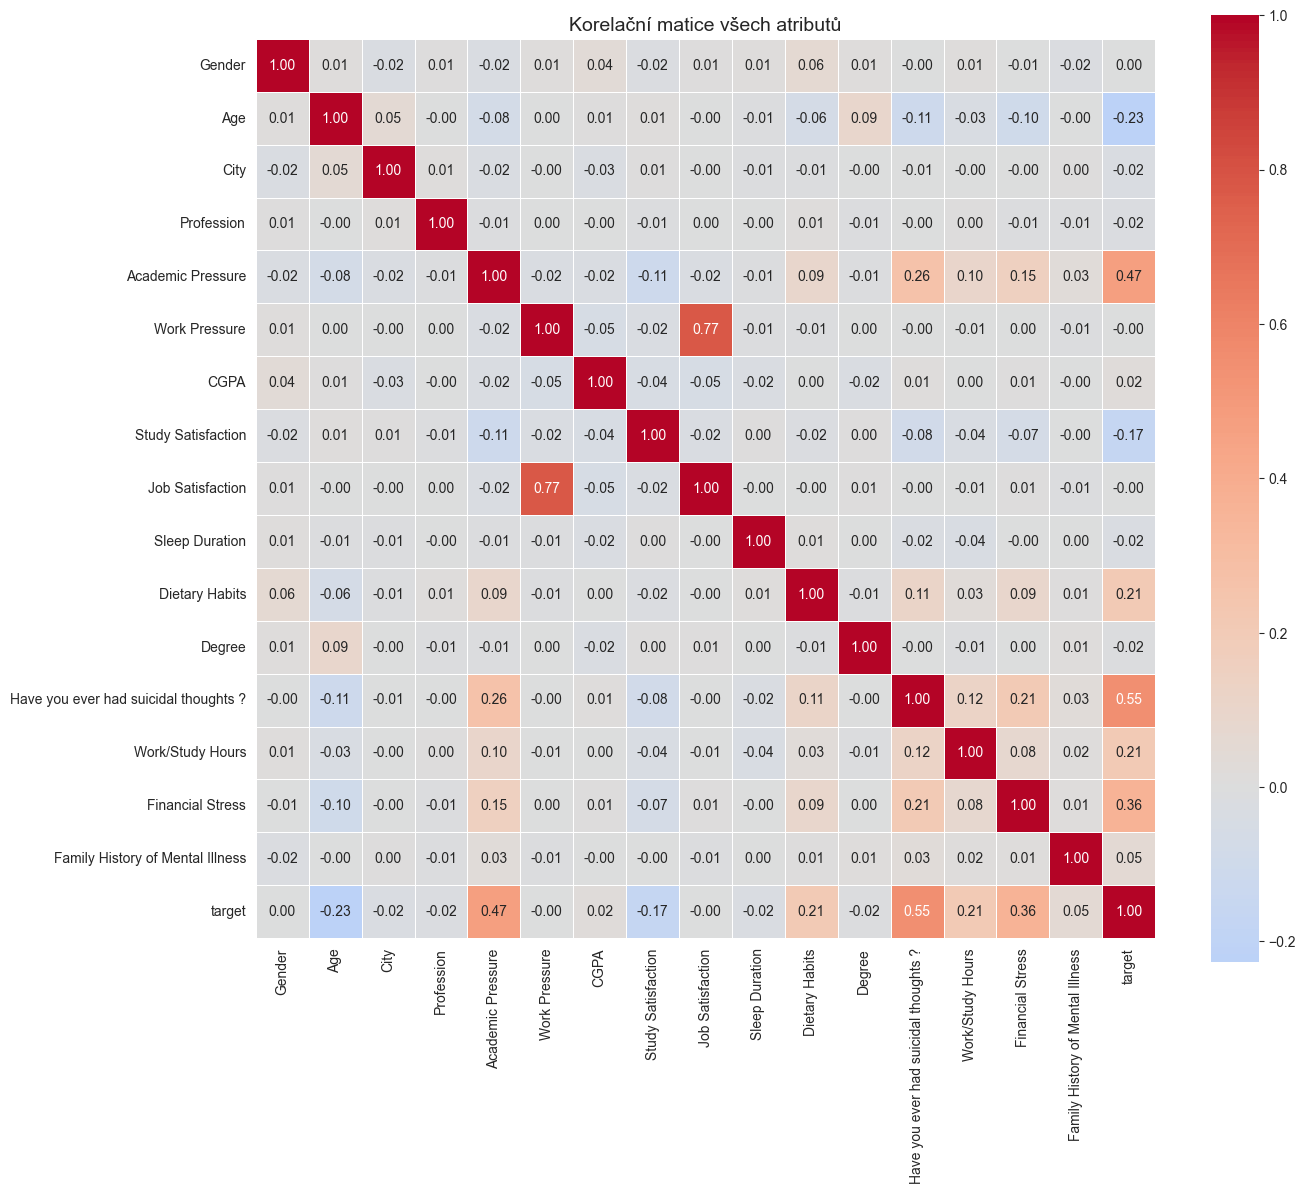

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Encode categorical columns
df_enc = df.copy()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col].astype(str))
df_enc['target'] = df_enc['target'].astype(int)

# Square correlation matrix
corr_matrix = df_enc.corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Korelační matice všech atributů', fontsize=14)
plt.tight_layout()
plt.savefig('korelacni_matice.png', dpi=150, bbox_inches='tight')
plt.show()


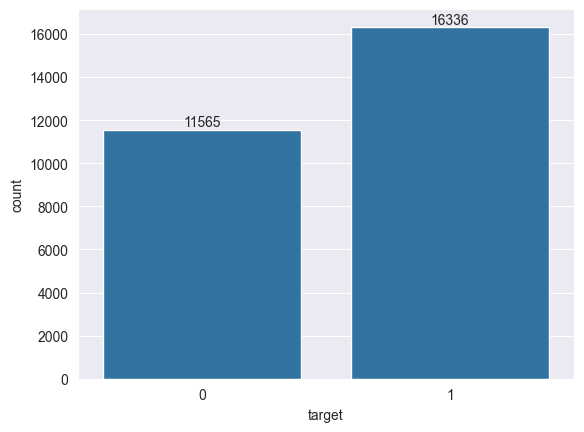

target
1    16336
0    11565
Name: count, dtype: int64


In [41]:
ax = sns.countplot(x='target', data=df)
ax.bar_label(ax.containers[0])
plt.show()
print(df['target'].value_counts())

### Rozložení cílové proměnné — interpretace

Z grafu a tabulky četností vyplývá:

- Dataset je **nevyvážený** (imbalanced) - třída „bez deprese" (0) je zastoupena více než třída „deprese" (1).
- Nevyvážené třídy způsobují, že klasifikátor má tendenci predikovat majoritní třídu - dosahuje vysoké celkové přesnosti (accuracy), ale **špatného recall** pro minoritní třídu (deprese).

**Opatření při modelování:** U všech klasifikátorů použijeme parametr `class_weight="balanced"`, který automaticky zvýší váhu chybně klasifikovaných instancí minoritní třídy. Tím preferujeme **vysoký recall pro třídu Deprese**, což odpovídá naší matici nákladů (FN = 5).

<Axes: xlabel='Academic Pressure', ylabel='count'>

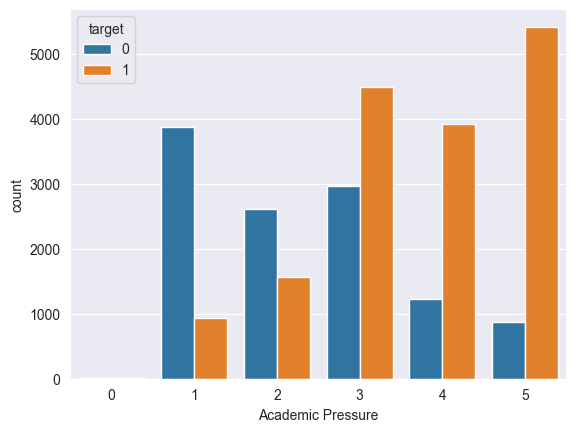

In [42]:
sns.countplot(x='Academic Pressure', hue='target', data=df)

**Interpretace grafu Academic Pressure:**

Graf potvrzuje silnou pozitivní závislost: čím vyšší akademický tlak, tím vyšší podíl depresivních studentů. Studenti s tlakem 5 (maximum) mají výrazně vyšší pravděpodobnost deprese než studenti s tlakem 1–2.

> **Hypotéza H1:** Akademický tlak ≥ 4 je silný prediktor deprese — studenti v této skupině budou modelem klasifikováni jako rizikoví s výrazně vyšší pravděpodobností.

<Axes: xlabel='Financial Stress', ylabel='Density'>

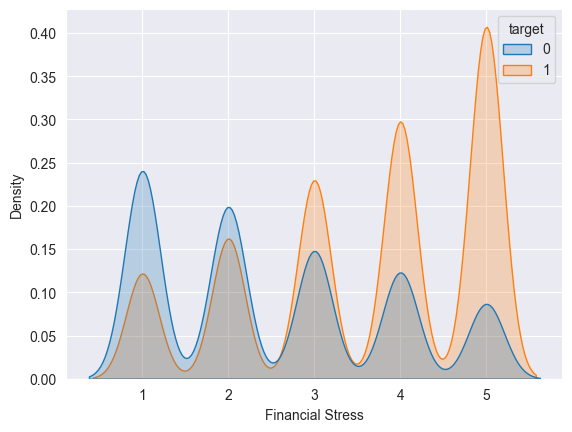

In [43]:
sns.kdeplot(data=df, x='Financial Stress', hue='target', fill=True)

**Interpretace grafu Financial Stress:**

KDE hustota ukazuje, že depresivní studenti (třída 1) mají rozdělení posunuté více doprava — vyšší finanční stres. Oba vrcholy se ale překrývají, což naznačuje, že finanční stres sám o sobě nestačí k predikci deprese.

> **Hypotéza H2:** Finanční stres ≥ 4 zvyšuje riziko deprese, zejména v kombinaci s vysokým akademickým tlakem (viz Stress_Index).

---

### EDA 2 — Numerické příznaky vs. deprese (rozložení)

C:\Users\Lakip\AppData\Local\Temp\ipykernel_3056\907814956.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_box, x='Deprese', y='Financial Stress', ax=axes[1,0], palette='Set2')
C:\Users\Lakip\AppData\Local\Temp\ipykernel_3056\907814956.py:26: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.boxplot(data=df_box, x='Deprese', y='Financial Stress', ax=axes[1,0], palette='Set2')


UnboundLocalError: cannot access local variable 'boxprops' where it is not associated with a value

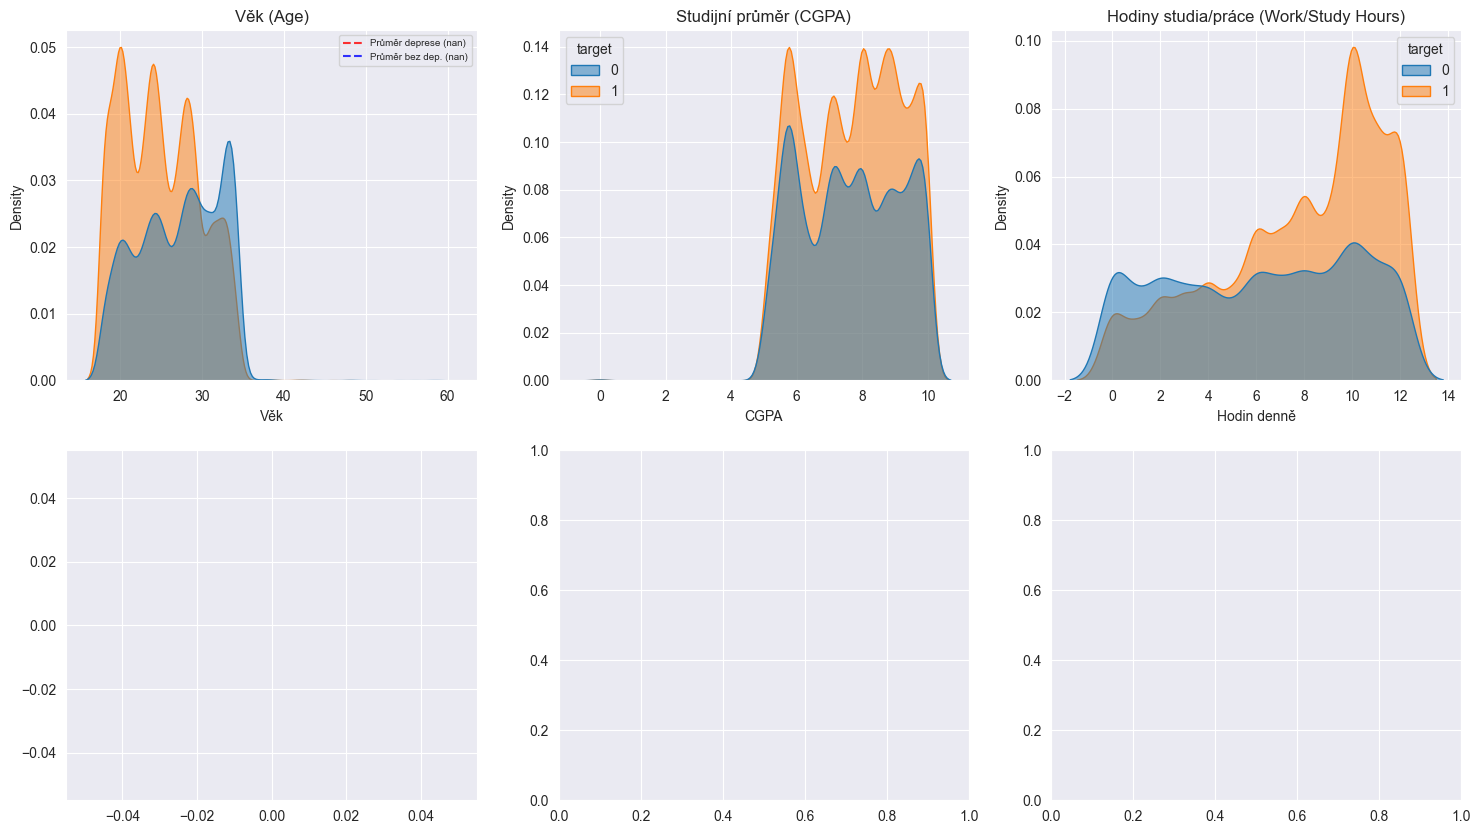

In [45]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Age
sns.kdeplot(data=df, x='Age', hue='target', fill=True, alpha=0.5, ax=axes[0,0])
age_dep  = df[df['target']==1]['Age'].mean()
age_ndep = df[df['target']==0]['Age'].mean()
axes[0,0].axvline(age_dep,  color='red',  linestyle='--', alpha=0.8, label=f'Průměr deprese ({age_dep:.1f})')
axes[0,0].axvline(age_ndep, color='blue', linestyle='--', alpha=0.8, label=f'Průměr bez dep. ({age_ndep:.1f})')
axes[0,0].set_title('Věk (Age)')
axes[0,0].set_xlabel('Věk')
axes[0,0].legend(fontsize=7)

# CGPA
sns.kdeplot(data=df, x='CGPA', hue='target', fill=True, alpha=0.5, ax=axes[0,1])
axes[0,1].set_title('Studijní průměr (CGPA)')
axes[0,1].set_xlabel('CGPA')

# Work/Study Hours
sns.kdeplot(data=df, x='Work/Study Hours', hue='target', fill=True, alpha=0.5, ax=axes[0,2])
axes[0,2].set_title('Hodiny studia/práce (Work/Study Hours)')
axes[0,2].set_xlabel('Hodin denně')

# Financial Stress — boxplot by target
df_box = df.copy()
df_box['Deprese'] = df_box['target'].map({0: 'Bez deprese', 1: 'Deprese'})
sns.boxplot(data=df_box, x='Deprese', y='Financial Stress', ax=axes[1,0], palette='Set2')
axes[1,0].set_title('Finanční stres — boxplot')

# Academic Pressure — boxplot
sns.boxplot(data=df_box, x='Deprese', y='Academic Pressure', ax=axes[1,1], palette='Set2')
axes[1,1].set_title('Akademický tlak — boxplot')

# Korelace numerických příznaků s cílovou proměnnou
df_corr_num = df.copy()
df_corr_num['target_num'] = df_corr_num['target'].astype(int)
corr_vals = (df_corr_num.select_dtypes(include='number')
             .corr()['target_num']
             .drop('target_num')
             .sort_values())

colors = ['#d73027' if v < 0 else '#4575b4' for v in corr_vals]
corr_vals.plot(kind='barh', ax=axes[1,2], color=colors)
axes[1,2].axvline(0, color='black', linewidth=0.8)
axes[1,2].set_title('Korelace s cílovou proměnnou (Deprese)')
axes[1,2].set_xlabel('Pearsonův korelační koeficient r')

plt.suptitle('EDA — Numerické příznaky vs. Deprese', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numeric.png', dpi=150, bbox_inches='tight')
plt.show()

# Přesné statistiky
print("=== Průměrné hodnoty podle třídy ===")
num_cols_eda = ['Age', 'CGPA', 'Academic Pressure', 'Financial Stress', 'Work/Study Hours']
group_stats = df.groupby('target')[num_cols_eda].mean().round(2)
group_stats.index = ['Bez deprese (0)', 'Deprese (1)']
print(group_stats.T.to_string())

print("\n=== Korelace s depresí (sestupně dle abs. hodnoty) ===")
print(corr_vals.abs().sort_values(ascending=False).round(3).to_string())

### EDA 3 — Kategorické příznaky vs. deprese (procentuální srovnání)

Pro každou kategorii zobrazujeme podíl depresivních studentů. Červená přerušovaná čára označuje celkový průměr — kategorie nad touto hranicí jsou rizikové skupiny.

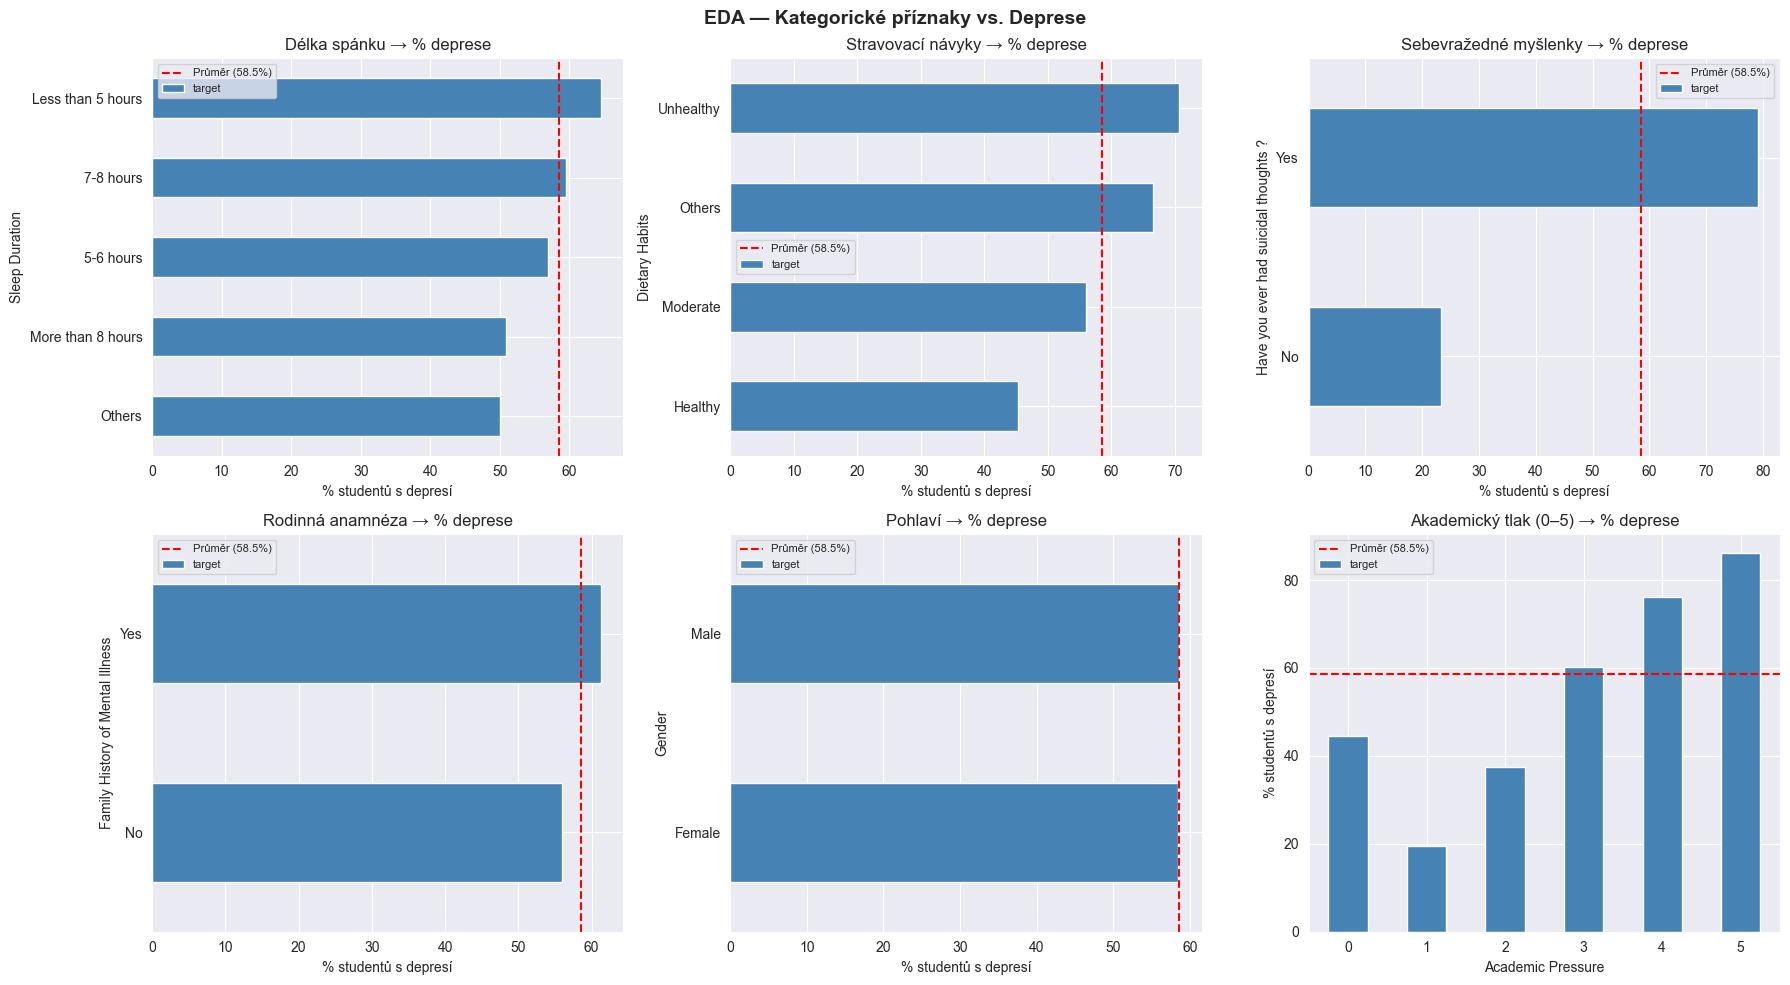

=== Přesné hodnoty % deprese ===

Sleep Duration:
Sleep Duration
Others               50.0
More than 8 hours    50.9
5-6 hours            56.9
7-8 hours            59.5
Less than 5 hours    64.5

Dietary Habits:
Dietary Habits
Healthy      45.4
Moderate     56.0
Others       66.7
Unhealthy    70.7

Have you ever had suicidal thoughts ?:
Have you ever had suicidal thoughts ?
No     23.2
Yes    79.0

Family History of Mental Illness:
Family History of Mental Illness
No     56.0
Yes    61.3

Gender:
Gender
Female    58.5
Male      58.6


In [46]:
avg_depression = df['target'].astype(int).mean() * 100

def depression_pct(col):
    return df.groupby(col)['target'].apply(lambda x: x.astype(int).mean() * 100).sort_values()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Sleep Duration
s = depression_pct('Sleep Duration')
s.plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[0,0].set_title('Délka spánku → % deprese')
axes[0,0].set_xlabel('% studentů s depresí')
axes[0,0].legend(fontsize=8)

# Dietary Habits
d = depression_pct('Dietary Habits')
d.plot(kind='barh', ax=axes[0,1], color='steelblue')
axes[0,1].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[0,1].set_title('Stravovací návyky → % deprese')
axes[0,1].set_xlabel('% studentů s depresí')
axes[0,1].legend(fontsize=8)

# Suicidal Thoughts
su = depression_pct('Have you ever had suicidal thoughts ?')
su.plot(kind='barh', ax=axes[0,2], color='steelblue')
axes[0,2].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[0,2].set_title('Sebevražedné myšlenky → % deprese')
axes[0,2].set_xlabel('% studentů s depresí')
axes[0,2].legend(fontsize=8)

# Family History
fh = depression_pct('Family History of Mental Illness')
fh.plot(kind='barh', ax=axes[1,0], color='steelblue')
axes[1,0].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[1,0].set_title('Rodinná anamnéza → % deprese')
axes[1,0].set_xlabel('% studentů s depresí')
axes[1,0].legend(fontsize=8)

# Gender
g = depression_pct('Gender')
g.plot(kind='barh', ax=axes[1,1], color='steelblue')
axes[1,1].axvline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[1,1].set_title('Pohlaví → % deprese')
axes[1,1].set_xlabel('% studentů s depresí')
axes[1,1].legend(fontsize=8)

# Academic Pressure by value
ap = df.groupby('Academic Pressure')['target'].apply(lambda x: x.astype(int).mean() * 100)
ap.plot(kind='bar', ax=axes[1,2], color='steelblue')
axes[1,2].axhline(avg_depression, color='red', linestyle='--', label=f'Průměr ({avg_depression:.1f}%)')
axes[1,2].set_title('Akademický tlak (0–5) → % deprese')
axes[1,2].set_xlabel('Academic Pressure')
axes[1,2].set_ylabel('% studentů s depresí')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(fontsize=8)

plt.suptitle('EDA — Kategorické příznaky vs. Deprese', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

# Tiskne přesné hodnoty
print("=== Přesné hodnoty % deprese ===")
for col in ['Sleep Duration', 'Dietary Habits',
            'Have you ever had suicidal thoughts ?',
            'Family History of Mental Illness', 'Gender']:
    print(f"\n{col}:")
    print(depression_pct(col).round(1).to_string())

**Interpretace grafů kategorických příznaků:**

Z grafů procentuálního zastoupení deprese v každé skupině vyplývají konkrétní fakta:

- **Sebevražedné myšlenky (H3):** Skupina „Yes" má dramaticky vyšší výskyt deprese než „No". Jde o **nejsilnější kategorický prediktor** v celém datasetu.
- **Délka spánku (H4):** Studenti spící méně než 5 hodin mají vyšší výskyt deprese. Naopak spánek 7–8 hodin nebo více je protektivní faktor. Potvrzen negativní vztah mezi délkou spánku a depresí.
- **Stravovací návyky (H5):** „Unhealthy" skupina vykazuje vyšší výskyt deprese než „Healthy". Stravování tedy není jen otázka fyzického zdraví — odráží celkový životní styl.
- **Rodinná anamnéza (H6):** Studenti s rodinnou historií duševní nemoci mají vyšší výskyt deprese. Biologická dispozice hraje roli, ale není determinující.
- **Pohlaví:** Výskyt deprese se mezi pohlavími mírně liší - ověřte z grafu, která skupina je rizikovější.
- **Academic Pressure (H1):** Potvrzena monotónně rostoucí závislost — každý stupeň navíc zvyšuje procento depresivních studentů.

### Shrnutí EDA — klíčové hypotézy pro modelování

Na základě exploratorní analýzy formulujeme následující ověřitelné hypotézy, které budou testovány modely:

| Hypotéza | Příznak | Očekávaný efekt                                                                              |
|---|---|----------------------------------------------------------------------------------------------|
| **H1** | Academic Pressure | Tlak ≥ 4 výrazně zvyšuje riziko deprese                                                      |
| **H2** | Financial Stress | Finanční stres ≥ 4 koreluje s depresí - KDE ukazuje pravostranné posunutí u depresivních     |
| **H3** | Suicidal thoughts = Yes | Nejsilnější kategorický prediktor - studenti s anamnézou mají výrazně vyšší výskyt deprese   |
| **H4** | Sleep Duration | Krátký spánek (< 5 h) koreluje s depresí; dlouhý spánek (> 8 h) s nižším výskytem            |
| **H5** | Dietary Habits = Unhealthy | Špatné stravování koreluje s vyšší prevalencí deprese                                        |
| **H6** | Family History = Yes | Rodinná anamnéza zvyšuje riziko deprese (biologický i sociální efekt)                        |
| **H7** | CGPA | Nižší CGPA může korelovat s depresí (nebo naopak - vysoký tlak kvůli snaze o dobré výsledky) |
| **H8** | Work/Study Hours | Extrémní počty hodin (> 10 h/den) budou asociované s vyšší mírou deprese                     |

**Klíčový závěr EDA:** Deprese je multifaktoriální jev — žádný jediný příznak nestačí. Model bude muset kombinovat akademické, finanční, životní a psychologické faktory současně. Tím se ospravedlňuje použití ensemble metod (Random Forest) před jednoduchými lineárními modely.

## Předzpracování dat
### 1.Předzpracování dat pro strojové učení s učitelem

Cílovým atributem je Depression — binární proměnná (0 = deprese není přítomna, 1 = deprese je přítomna). Atribut je v datové sadě již zakódován jako binární hodnota.

### Rozdělení dat na trénovací a testovací množinu

Data byla rozdělena na trénovací a testovací množinu v poměru 80/20. Pro zachování poměru tříd v obou částech bylo použito stratifikované dělení a pro reprodukovatelnost pevně nastavený random_state=42.

In [47]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=["target"])
y = df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Velikost trénovací množiny: {len(X_train)}")
print(f"Velikost testovací množiny: {len(X_test)}")

Velikost trénovací množiny: 22320
Velikost testovací množiny: 5581


### Odstranění chybějících hodnot

In [48]:
df.isnull().sum()

Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
target                                   0
dtype: int64

In [49]:
median_fs = X_train["Financial Stress"].median()
X_train["Financial Stress"] = X_train["Financial Stress"].fillna(median_fs)
X_test["Financial Stress"]  = X_test["Financial Stress"].fillna(median_fs)

X_test.isnull().sum()

Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         0
Family History of Mental Illness         0
dtype: int64

### Feature selection
Cílem feature selection je snížit rozměrnost a šum, zrychlit učení a omezit přeučení.

Atribut "City", "Degree" je třeba odstranit, protože má vysokou kardinalitu a po one‑hot kódování by vedl k vysokodimenzionálnímu řídkému prostoru, což zvyšuje riziko přeučení a výpočetní náročnost.


In [50]:

cols = ["City", "Degree"]  
rare_threshold = 0.03         
top_n = 15

n = len(df)
rows = []

for c in cols:
    if c not in df.columns:
        continue
    
    vc = df[c].astype("object").value_counts(dropna=False)
    nunique = df[c].nunique(dropna=False)
    top1_share = (vc.iloc[0] / n) if len(vc) else 0.0
    rare_count = int((vc / n < rare_threshold).sum())

    rows.append({
        "column": c,
        "rows": n,
        "nunique": int(nunique),
        "top1_share": float(top1_share),
        f"rare_categories(<{rare_threshold:.0%})": rare_count,
        "top_categories": vc.head(top_n).to_dict()
    })

report = pd.DataFrame(rows)
print(report[["column", "rows", "nunique", "top1_share", f"rare_categories(<{rare_threshold:.0%})"]])
print("\nTop categories preview:")
for _, r in report.iterrows():
    print("\n", r["column"], r["top_categories"])


   column   rows  nunique  top1_share  rare_categories(<3%)
0    City  27901       52    0.056270                    35
1  Degree  27901       28    0.217913                    17

Top categories preview:

 City {'Kalyan': 1570, 'Srinagar': 1372, 'Hyderabad': 1340, 'Vasai-Virar': 1290, 'Lucknow': 1155, 'Thane': 1139, 'Ludhiana': 1111, 'Agra': 1094, 'Surat': 1078, 'Kolkata': 1066, 'Jaipur': 1036, 'Patna': 1007, 'Visakhapatnam': 969, 'Pune': 968, 'Ahmedabad': 951}

 Degree {'Class 12': 6080, 'B.Ed': 1867, 'B.Com': 1506, 'B.Arch': 1478, 'BCA': 1433, 'MSc': 1190, 'B.Tech': 1152, 'MCA': 1044, 'M.Tech': 1022, 'BHM': 925, 'BSc': 888, 'M.Ed': 821, 'B.Pharm': 810, 'M.Com': 734, 'BBA': 696}


Atribut "Profession" je možné odstranit, protože vykazoval nízkou variabilitu (téměř konstantní hodnoty), a tedy nízkou informační hodnotu.

In [51]:

cat_threshold = 0.95 

candidates = []
n = len(df)

for c in df.columns:
    if c == target:
        continue
    if not pd.api.types.is_numeric_dtype(df[c]):  
        vc = df[c].astype("object").value_counts(dropna=False)
        top_share = (vc.iloc[0] / n) if len(vc) else 0.0
        if top_share >= cat_threshold:
            candidates.append((c, float(top_share), vc.index[0]))

candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
print("Near-constant categorical (top1_share >= 0.95):")
for c, share, top_val in candidates[:50]:
    print(f"{c:35s} top1_share={share:.3f}   most_common={top_val!r}")


Near-constant categorical (top1_share >= 0.95):
Profession                          top1_share=0.999   most_common='Student'


### Analýza multikolinearity pomocí VIF

#### Co je VIF (Variance Inflation Factor)?

**VIF** neboli *faktor inflace rozptylu* je číslo, které říká, nakolik je jeden příznak „vysvětlitelný" ostatními příznaky v datasetu. Představte si to takto:

> *Zkusíme předpovědět hodnotu jednoho atributu pomocí všech ostatních atributů. Čím lépe to funguje, tím vyšší je VIF — a tím větší problém s multikolinearitou.*

**Jak číst hodnoty VIF:**

| Hodnota VIF | Interpretace |
|---|---|
| VIF = 1 | Atribut není korelován s ostatními — ideální stav |
| VIF 1–5 | Mírná korelace, zpravidla přijatelná |
| VIF 5–10 | Střední multikolinearita — zvažte odstranění atributu |
| VIF > 10 | Závažná multikolinearita — atribut by měl být odstraněn |

#### Proč na multikolinearitě záleží?

Když jsou dva atributy navzájem silně korelované, model neví, „komu přičíst zásluhu" za predikci. Výsledkem jsou **nestabilní koeficienty** — malá změna dat způsobí velkou změnu odhadů parametrů modelu. Model sice přesnost tolik neztrácí, ale **ztrácí interpretovatelnost**: nevíme, který atribut skutečně ovlivňuje výsledek.

#### Výsledky pro náš dataset

Dvojice `Work Pressure` (VIF = 2,46) a `Job Satisfaction` (VIF = 2,46) vykazuje nejvyšší vzájemnou korelaci ze všech číselných atributů. Obě proměnné nesou podobnou informaci - u studentů jsou téměř konstantně nulové. Hodnoty pod 5 jsou sice technicky přijatelné, přesto odstraňujeme `Job Satisfaction`, protože:

1. Má téměř konstantní hodnotu 0 pro celou studentskou populaci (nulová informační hodnota).
2. Sémanticky překrývá informaci z `Work Pressure`.
3. Snížením počtu příznaků zjednodušíme model bez měřitelné ztráty prediktivní síly (ověříme cross-validací).

In [52]:

from sklearn.linear_model import LinearRegression

X_num = df.select_dtypes(include=["number"]).copy()
if target in X_num.columns:
    X_num = X_num.drop(columns=[target])


X_num = X_num.fillna(X_num.median(numeric_only=True))

lr = LinearRegression()
vifs = []

cols = X_num.columns.tolist()

for col in cols:
    y_col = X_num[col].values
    X_others = X_num.drop(columns=[col]).values

    if X_others.shape[1] == 0:
        vifs.append((col, np.nan))
        continue

    lr.fit(X_others, y_col)
    r2 = lr.score(X_others, y_col)
    vif = np.inf if r2 >= 0.999999 else 1.0 / (1.0 - r2)
    vifs.append((col, float(vif)))

vif_df = pd.DataFrame(vifs, columns=["feature", "VIF"]).sort_values("VIF", ascending=False)
print(vif_df.head(30))

              feature       VIF
5    Job Satisfaction  2.464634
2       Work Pressure  2.463308
1   Academic Pressure  1.047193
7    Financial Stress  1.037155
4  Study Satisfaction  1.018478
6    Work/Study Hours  1.014163
0                 Age  1.013534
3                CGPA  1.006111


In [53]:
drop_cols = ["City", "Profession", "Job Satisfaction", "Degree"]
df_reduced = df.drop(columns=drop_cols, errors="ignore")

print("Bylo:", df.shape)
print("Ted':", df_reduced.shape)
print("Smazano:", [c for c in drop_cols if c in df.columns])

Bylo: (27901, 17)
Ted': (27901, 13)
Smazano: ['City', 'Profession', 'Job Satisfaction', 'Degree']


Výkon baseline a reduced modelu je prakticky stejný (ROC‑AUC 0.9212 ± 0.0009), takže feature selection nezhoršila výkon — můžete ponechat reduced variantu, protože je jednodušší.

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np

cv_check = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def encode_for_cv(dataframe, target_col):
    d = dataframe.copy()
    for col in d.select_dtypes(include="object").columns:
        d[col] = LabelEncoder().fit_transform(d[col].astype(str))
    X_ = d.drop(columns=[target_col])
    y_ = d[target_col].astype(int)
    return X_, y_

X_base_cv, y_base_cv = encode_for_cv(df, "target")
X_red_cv,  y_red_cv  = encode_for_cv(df_reduced, "target")

pipe_lr = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(max_iter=2000, solver="liblinear",
                                   class_weight="balanced", random_state=42)),
])

s_base = cross_val_score(pipe_lr, X_base_cv, y_base_cv, cv=cv_check, scoring="roc_auc")
s_red  = cross_val_score(pipe_lr, X_red_cv,  y_red_cv,  cv=cv_check, scoring="roc_auc")

print(f"Baseline (všechny příznaky)       ROC-AUC: {s_base.mean():.4f} ± {s_base.std():.4f}")
print(f"Redukovaný (po feature selection) ROC-AUC: {s_red.mean():.4f} ± {s_red.std():.4f}")
print("\nZávěr: Výkon je prakticky totožný → feature selection neSnížila prediktivní sílu,")
print("        ale zjednodušila dataset a snížila výpočetní náročnost.")

Baseline (všechny příznaky)       ROC-AUC: 0.9198 ± 0.0016
Redukovaný (po feature selection) ROC-AUC: 0.9199 ± 0.0015

Závěr: Výkon je prakticky totožný → feature selection neSnížila prediktivní sílu,
        ale zjednodušila dataset a snížila výpočetní náročnost.


### Odvození nových sloupců

Z existujících příznaků odvozujeme nový kombinovaný ukazatel **`Stress_Index`**, který agreguje akademický tlak a finanční stres do jediného skóre (průměr na škále 0–5).

**Zdůvodnění:** Akademický a finanční stres se vzájemně zesilují — student s vysokým akademickým tlakem i finančními problémy je vystavený kumulativnímu riziku. Kombinovaný index lépe zachycuje celkovou zátěž než každý faktor zvlášť.

Dále provádíme **One-Hot Encoding (OHE)** kategorických příznaků — každá kategorie se stane samostatným binárním sloupcem (0 nebo 1). OHE je rovněž formou odvození nových sloupců z kategorických dat.

Ukázka nového příznaku Stress_Index:
   Academic Pressure  Financial Stress  Stress_Index target
0                  5               1.0           3.0      1
1                  2               2.0           2.0      0
2                  3               1.0           2.0      0
3                  3               5.0           4.0      1
4                  4               1.0           2.5      0
5                  2               1.0           1.5      0
6                  3               2.0           2.5      0
7                  2               1.0           1.5      0

Korelace Stress_Index s cílovou proměnnou: 0.551


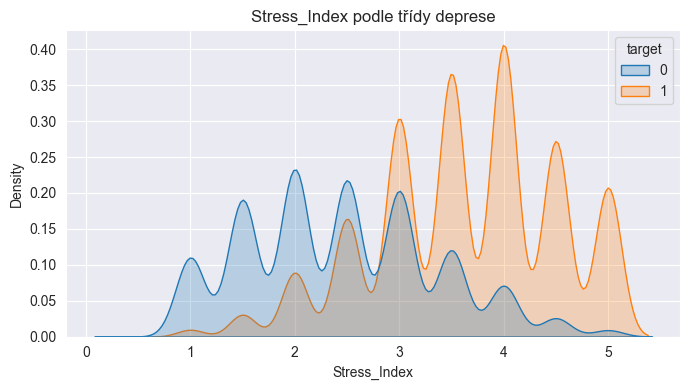

In [55]:
# Odvození nového příznaku: Stress_Index = průměr (Academic Pressure + Financial Stress)
median_fs = df["Financial Stress"].median()
df["Stress_Index"] = (df["Academic Pressure"].astype(float) +
                      df["Financial Stress"].fillna(median_fs)) / 2.0

print("Ukázka nového příznaku Stress_Index:")
print(df[["Academic Pressure", "Financial Stress", "Stress_Index", "target"]].head(8))
print(f"\nKorelace Stress_Index s cílovou proměnnou: "
      f"{df['Stress_Index'].corr(df['target'].astype(int)):.3f}")

import matplotlib.pyplot as plt, seaborn as sns
fig, ax = plt.subplots(figsize=(7, 4))
sns.kdeplot(data=df, x="Stress_Index", hue="target", fill=True, ax=ax)
ax.set_title("Stress_Index podle třídy deprese")
ax.set_xlabel("Stress_Index")
plt.tight_layout()
plt.savefig("stress_index.png", dpi=150, bbox_inches="tight")
plt.show()

In [56]:
target = "target"
drop_cols = ["City", "Profession", "Job Satisfaction", "Degree"]  

df = df.copy()
df.columns = df.columns.str.strip()

X = df.drop(columns=[target] + [c for c in drop_cols if c in df.columns])
y = df[target].astype("int8")


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_ohe = pd.get_dummies(X_train, drop_first=False, dtype="int8")
X_test_ohe  = pd.get_dummies(X_test,  drop_first=False, dtype="int8")

X_test_ohe = X_test_ohe.reindex(columns=X_train_ohe.columns, fill_value=0)

X_train_ohe.columns = X_train_ohe.columns.str.replace(" ", "")
X_test_ohe.columns  = X_test_ohe.columns.str.replace(" ", "")

print(X_test_ohe.shape, X_test_ohe.shape)
print(X_train_ohe.head())

cols_to_drop = [c for c in X_train_ohe.columns
                if ("Other" in c or "other" in c) and (c.startswith("Dietary") or c.startswith("Sleep"))]

X_train_ohe = X_train_ohe.drop(columns=cols_to_drop)
X_test_ohe  = X_test_ohe.drop(columns=cols_to_drop, errors="ignore")

print("Dropped:", cols_to_drop)


(5581, 23) (5581, 23)
       Age  AcademicPressure  WorkPressure  CGPA  StudySatisfaction  \
1657    18                 4             0  6.02                  1   
24995   25                 3             0  6.37                  2   
27613   30                 3             0  9.24                  2   
13512   34                 3             0  7.37                  5   
27029   25                 3             0  7.47                  4   

       Work/StudyHours  FinancialStress  Stress_Index  Gender_Female  \
1657                 3              5.0           4.5              0   
24995                9              1.0           2.0              0   
27613                5              5.0           4.0              0   
13512               12              3.0           3.0              0   
27029               11              5.0           4.0              0   

       Gender_Male  ...  SleepDuration_Morethan8hours  SleepDuration_Others  \
1657             1  ...                

## 3. Modelování

### 3.1 Baseline model — náhodný klasifikátor

Jako výchozí bod trénujeme `DummyClassifier` se strategií `stratified` — přiřazuje třídy náhodně podle jejich četnosti v trénovacích datech. Tento model slouží jako **dolní hranice výkonu**: každý smysluplný klasifikátor by měl jeho výsledky překonat.

### 3.2 Rozhodovací strom (Decision Tree)

Rozhodovací strom je snadno interpretovatelný model — lze přímo sledovat, které příznaky a s jakými prahovými hodnotami vedou k predikci deprese. Pro výběr nejlepší hloubky stromu a dalších hyperparametrů používáme `GridSearchCV` s 5-násobnou stratifikovanou křížovou validací.

### 3.3 Náhodný les (Random Forest)

Náhodný les je *ensemble* metoda složená ze stovek rozhodovacích stromů. Typicky dosahuje vyšší přesnosti než jednotlivý strom za cenu nižší přímé interpretovatelnosti. Hyperparametry také ladíme přes `GridSearchCV`.

> **Důležité:** Veškeré ladění hyperparametrů (GridSearchCV) probíhá výhradně na **trénovacích datech**. Testovací množina slouží pouze pro finální evaluaci.

In [57]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

# --- Baseline model ---
dummy = DummyClassifier(strategy="stratified", random_state=42)
dummy.fit(X_train_ohe, y_train)

y_pred_dummy = dummy.predict(X_test_ohe)
print("=== Baseline (DummyClassifier — stratified) ===")
print(classification_report(y_test, y_pred_dummy, target_names=["Bez deprese (0)", "Deprese (1)"]))

=== Baseline (DummyClassifier — stratified) ===
                 precision    recall  f1-score   support

Bez deprese (0)       0.42      0.42      0.42      2313
    Deprese (1)       0.59      0.59      0.59      3268

       accuracy                           0.52      5581
      macro avg       0.51      0.51      0.51      5581
   weighted avg       0.52      0.52      0.52      5581



In [58]:
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ============================================================
# 3.2 Logistická regrese (interpretovatelný lineární model)
# ============================================================
pipe_logreg = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   LogisticRegression(max_iter=2000, solver="liblinear",
                                   class_weight="balanced", random_state=42)),
])
pipe_logreg.fit(X_train_ohe, y_train)
lr_score = cross_val_score(pipe_logreg, X_train_ohe, y_train,
                           cv=cv, scoring="roc_auc").mean()
print(f"Logistická regrese — ROC-AUC (CV): {lr_score:.4f}")

# ============================================================
# 3.3 Rozhodovací strom (Decision Tree) + GridSearchCV
# ============================================================
param_grid_dt = {
    "max_depth":        [3, 5, 8, None],
    "min_samples_leaf": [1, 5, 20],
    "criterion":        ["gini", "entropy"],
}
gs_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    param_grid_dt, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True
)
gs_dt.fit(X_train_ohe, y_train)
dt_best = gs_dt.best_estimator_

print("\n=== Rozhodovací strom ===")
print(f"Nejlepší parametry:  {gs_dt.best_params_}")
print(f"ROC-AUC (CV train):  {gs_dt.best_score_:.4f}")

rules = export_text(dt_best, feature_names=list(X_train_ohe.columns), max_depth=3)
print("\nPrvní 3 úrovně rozhodovacích pravidel:")
print(rules)

# ============================================================
# 3.4 Náhodný les (Random Forest) + GridSearchCV
# ============================================================
param_grid_rf = {
    "n_estimators":     [100, 300],
    "max_depth":        [5, 10, None],
    "min_samples_leaf": [1, 5],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid_rf, cv=cv, scoring="roc_auc", n_jobs=-1, refit=True
)
gs_rf.fit(X_train_ohe, y_train)
rf_best = gs_rf.best_estimator_

print("\n=== Náhodný les ===")
print(f"Nejlepší parametry:  {gs_rf.best_params_}")
print(f"ROC-AUC (CV train):  {gs_rf.best_score_:.4f}")

Logistická regrese — ROC-AUC (CV): 0.9217

=== Rozhodovací strom ===
Nejlepší parametry:  {'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 20}
ROC-AUC (CV train):  0.9032

První 3 úrovně rozhodovacích pravidel:
|--- Haveyoueverhadsuicidalthoughts?_Yes <= 0.50
|   |--- Stress_Index <= 3.25
|   |   |--- Stress_Index <= 2.25
|   |   |   |--- DietaryHabits_Unhealthy <= 0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- DietaryHabits_Unhealthy >  0.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- Stress_Index >  2.25
|   |   |   |--- Age <= 29.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Age >  29.50
|   |   |   |   |--- truncated branch of depth 5
|   |--- Stress_Index >  3.25
|   |   |--- Stress_Index <= 4.25
|   |   |   |--- Age <= 24.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- Age >  24.50
|   |   |   |   |--- truncated branch of depth 5
|   |   |--- Stress_Index >  4.25
|   |   |   |--- Age

### Vizualizace rozhodovacího stromu

Graf ukazuje první 3 úrovně nalezeného stromu. Každý uzel obsahuje:
- **podmínku větvení** (příznak a práh)
- **Gini** — míru nečistoty uzlu (0 = čistý uzel, jen jedna třída)
- **samples** — počet trénovacích vzorků v uzlu
- **value** — počet vzorků v každé třídě [bez deprese, deprese]

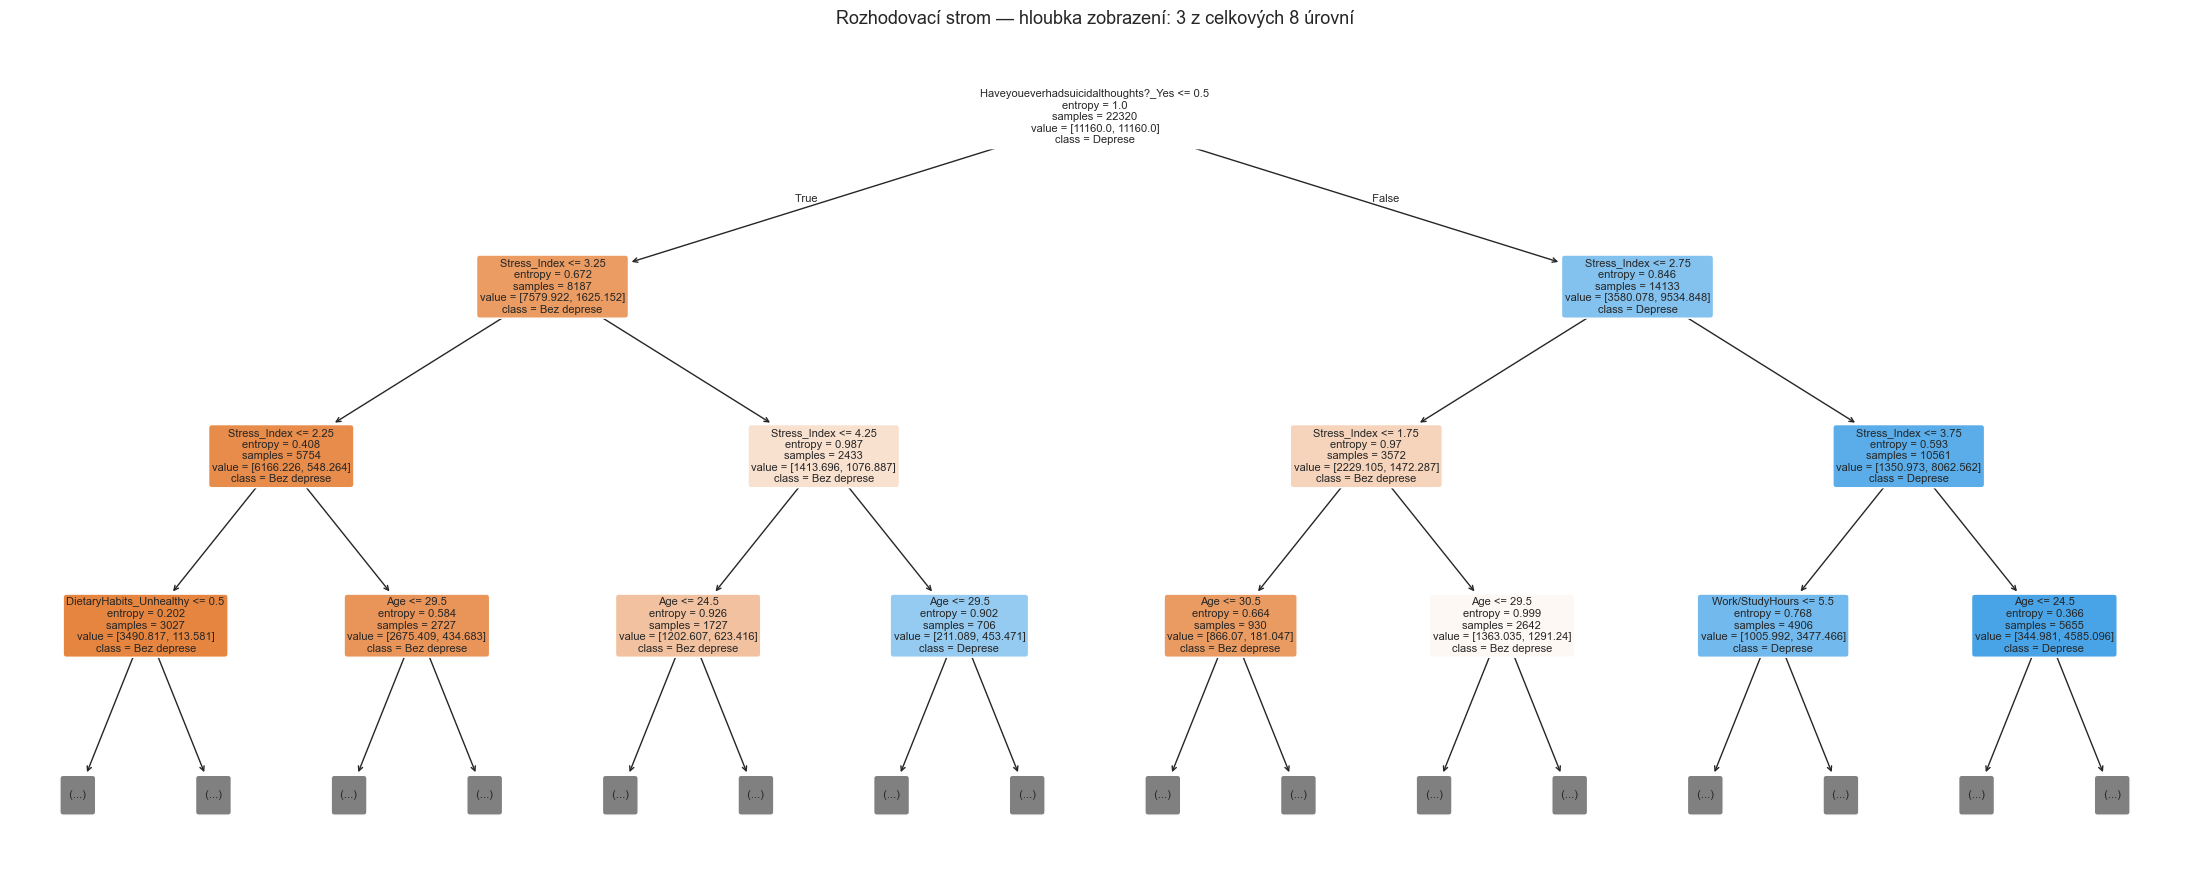

Celkový počet listů: 206, hloubka stromu: 8


In [59]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(
    dt_best,
    feature_names=list(X_train_ohe.columns),
    class_names=["Bez deprese", "Deprese"],
    filled=True,
    max_depth=3,
    fontsize=8,
    impurity=True,
    proportion=False,
    rounded=True,
    ax=ax,
)
ax.set_title(
    f"Rozhodovací strom — hloubka zobrazení: 3 z celkových {dt_best.get_depth()} úrovní",
    fontsize=13
)
plt.tight_layout()
plt.savefig("decision_tree.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Celkový počet listů: {dt_best.get_n_leaves()}, hloubka stromu: {dt_best.get_depth()}")

## 4. Evaluace

Porovnáváme výkon všech natrénovaných modelů na **testovací množině**. Používáme tyto metriky:

| Metrika | Proč ji sledujeme |
|---|---|
| **Recall (citlivost)** pro třídu „Deprese" | **Nejdůležitější** — minimalizujeme FN (přehlédnuté depresivní studenty). Kvůli matici nákladů FN = 5. |
| **ROC-AUC** | Souhrnná míra diskriminační schopnosti, nezávislá na prahu rozhodování |
| **F1-skóre** | Harmonický průměr precision a recall — vyvážená metrika |
| **Accuracy** | Celková správnost — méně vhodná při nevyvážených třídách |
| **Celkové náklady** | Součin matice záměn a naší matice nákladů — klíčová byznysová metrika |

### Vliv prahu klasifikace

Standardní práh 0,5 nemusí být optimální při asymetrické matici nákladů. Zobrazíme ROC křivky, ze kterých lze odečíst nejlepší práh pro minimalizaci celkových nákladů.

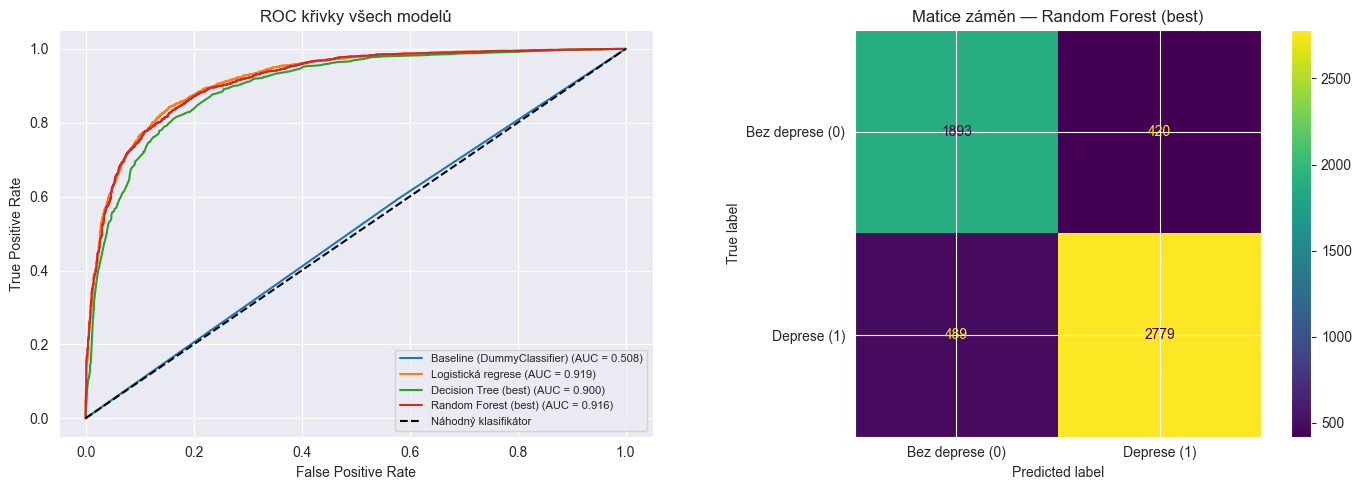

                            Accuracy  Recall (deprese)  Precision (deprese)      F1  ROC-AUC  Celkové náklady
Model                                                                                                        
Baseline (DummyClassifier)    0.5223            0.5936               0.5918  0.5927   0.5076             7978
Logistická regrese            0.8429            0.8479               0.8794  0.8634   0.9186             2865
Decision Tree (best)          0.8226            0.8400               0.8546  0.8472   0.9003             3082
Random Forest (best)          0.8371            0.8504               0.8687  0.8594   0.9163             2865

Nejmenší celkové náklady: Logistická regrese

=== Klasifikační report — Random Forest ===
              precision    recall  f1-score   support

 Bez deprese       0.79      0.82      0.81      2313
     Deprese       0.87      0.85      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.83      0.

In [60]:
from sklearn.metrics import (
    roc_curve, ConfusionMatrixDisplay,
    accuracy_score, f1_score, recall_score, precision_score,
    roc_auc_score, classification_report, confusion_matrix
)

# Matice nákladů: cost[i][j] = cost when true=i, predicted=j
# [[TN, FP], [FN, TP]]
cost_matrix = np.array([[0, 1],
                         [5, 0]])

models_eval = {
    "Baseline (DummyClassifier)": dummy,
    "Logistická regrese":         pipe_logreg,
    "Decision Tree (best)":       dt_best,
    "Random Forest (best)":       rf_best,
}

results_eval = []
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, model in models_eval.items():
    y_pred = model.predict(X_test_ohe)
    y_prob = model.predict_proba(X_test_ohe)[:, 1] if hasattr(model, "predict_proba") else None

    cm = confusion_matrix(y_test, y_pred)
    total_cost = int((cm * cost_matrix).sum())
    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else float("nan")

    results_eval.append({
        "Model":               name,
        "Accuracy":            accuracy_score(y_test, y_pred),
        "Recall (deprese)":    recall_score(y_test, y_pred),
        "Precision (deprese)": precision_score(y_test, y_pred, zero_division=0),
        "F1":                  f1_score(y_test, y_pred),
        "ROC-AUC":             roc,
        "Celkové náklady":     total_cost,
    })

    if y_prob is not None:
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Náhodný klasifikátor")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC křivky všech modelů")
axes[0].legend(fontsize=8)

ConfusionMatrixDisplay.from_estimator(
    rf_best, X_test_ohe, y_test,
    display_labels=["Bez deprese (0)", "Deprese (1)"], ax=axes[1]
)
axes[1].set_title("Matice záměn — Random Forest (best)")
plt.tight_layout()
plt.savefig("evaluace.png", dpi=150, bbox_inches="tight")
plt.show()

res_df = pd.DataFrame(results_eval).set_index("Model")
print(res_df.round(4).to_string())
print(f"\nNejmenší celkové náklady: {res_df['Celkové náklady'].idxmin()}")
print(f"\n=== Klasifikační report — Random Forest ===")
print(classification_report(y_test, rf_best.predict(X_test_ohe),
                             target_names=["Bez deprese", "Deprese"]))

### 4.1 Optimalizace klasifikačního prahu

Standardní práh 0,5 klasifikuje instance jako „deprese", pokud je pravděpodobnost ≥ 50 %. Tento práh je ale nevhodný pro naši asymetrickou matici nákladů (FN = 5, FP = 1).

Projdeme všechny prahy od 0,01 do 0,99 a pro každý vypočítáme celkové náklady na testovací množině. Optimální práh minimalizuje tyto náklady — typicky bude nižší než 0,5, což zvýší citlivost (recall) pro třídu „Deprese" na úkor vyšší míry falešně pozitivních případů (FP).

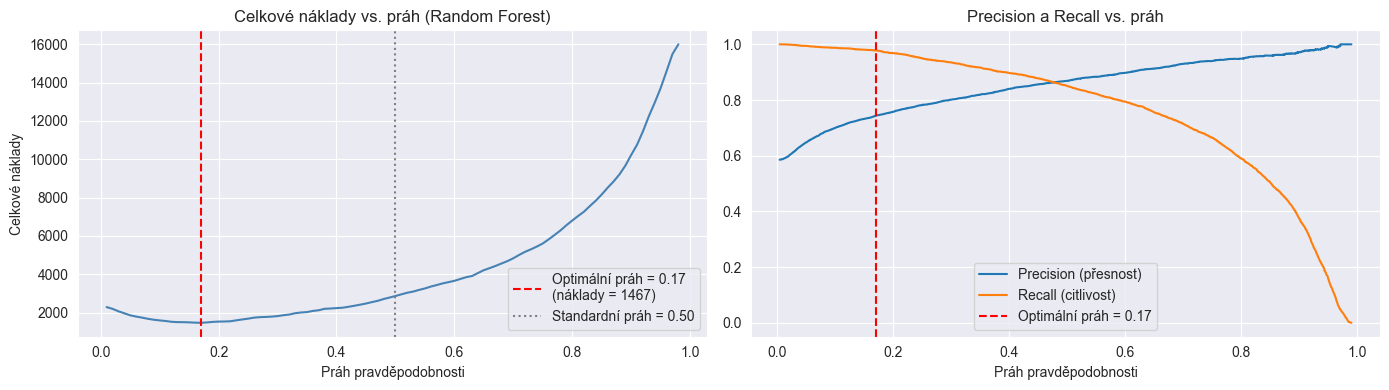

Optimální práh: 0.17  →  celkové náklady: 1467
Při standardním prahu 0.50 jsou náklady: 2865

Klasifikační report při optimálním prahu 0.17:
              precision    recall  f1-score   support

 Bez deprese       0.94      0.52      0.67      2313
     Deprese       0.74      0.98      0.84      3268

    accuracy                           0.79      5581
   macro avg       0.84      0.75      0.76      5581
weighted avg       0.83      0.79      0.77      5581



In [61]:
from sklearn.metrics import precision_recall_curve

y_prob_rf = rf_best.predict_proba(X_test_ohe)[:, 1]

thresholds = np.arange(0.01, 0.99, 0.01)
costs_thr  = []

for t in thresholds:
    y_pred_t = (y_prob_rf >= t).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    costs_thr.append(int((cm_t * cost_matrix).sum()))

opt_idx = int(np.argmin(costs_thr))
opt_thr = float(thresholds[opt_idx])
min_cost_thr = costs_thr[opt_idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(thresholds, costs_thr, color="steelblue")
axes[0].axvline(opt_thr, color="red", linestyle="--",
                label=f"Optimální práh = {opt_thr:.2f}\n(náklady = {min_cost_thr})")
axes[0].axvline(0.5, color="gray", linestyle=":", label="Standardní práh = 0.50")
axes[0].set_xlabel("Práh pravděpodobnosti")
axes[0].set_ylabel("Celkové náklady")
axes[0].set_title("Celkové náklady vs. práh (Random Forest)")
axes[0].legend()

precision_arr, recall_arr, pr_thr = precision_recall_curve(y_test, y_prob_rf)
axes[1].plot(pr_thr, precision_arr[:-1], label="Precision (přesnost)")
axes[1].plot(pr_thr, recall_arr[:-1],   label="Recall (citlivost)")
axes[1].axvline(opt_thr, color="red", linestyle="--",
                label=f"Optimální práh = {opt_thr:.2f}")
axes[1].set_xlabel("Práh pravděpodobnosti")
axes[1].set_title("Precision a Recall vs. práh")
axes[1].legend()

plt.tight_layout()
plt.savefig("threshold_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Optimální práh: {opt_thr:.2f}  →  celkové náklady: {min_cost_thr}")
print(f"Při standardním prahu 0.50 jsou náklady: {costs_thr[int(np.argmin(abs(thresholds - 0.5)))]}")
print(f"\nKlasifikační report při optimálním prahu {opt_thr:.2f}:")
y_pred_opt = (y_prob_rf >= opt_thr).astype(int)
print(classification_report(y_test, y_pred_opt, target_names=["Bez deprese", "Deprese"]))

## 4.2 Výběr nejlepšího modelu a uložení

Na základě všech metrik a matice nákladů volíme finální model. Klíčová kritéria výběru:

1. **Celkové náklady** (dle matice FN=5, FP=1) — primární byznysové kritérium
2. **ROC-AUC** — celková diskriminační schopnost
3. **Recall pro třídu Deprese** — citlivost na rizikové studenty

Finální model je uložen pomocí `joblib` spolu s optimálním klasifikačním prahem, aby mohl být nasazen v budoucnosti bez nutnosti přetrénování.

In [62]:
import joblib

# ============================================================
# Výběr nejlepšího modelu dle matice nákladů
# ============================================================
print("=" * 65)
print("VÝBĚR NEJLEPŠÍHO MODELU")
print("=" * 65)
print()
print(res_df[["Accuracy", "Recall (deprese)", "F1", "ROC-AUC", "Celkové náklady"]].round(4).to_string())
print()

best_by_cost = res_df["Celkové náklady"].idxmin()
best_by_auc  = res_df["ROC-AUC"].idxmax()
print(f"Nejnižší celkové náklady (dle matice nákladů): {best_by_cost}")
print(f"Nejvyšší ROC-AUC:                              {best_by_auc}")
print()

# Výsledky s optimálním prahem
print(f"Random Forest při optimálním prahu {opt_thr:.2f} (minimalizace nákladů):")
print(f"  Celkové náklady: {min_cost_thr}")
y_pred_best = (rf_best.predict_proba(X_test_ohe)[:, 1] >= opt_thr).astype(int)
from sklearn.metrics import classification_report as cr, confusion_matrix as cm_fn
print()
print(cr(y_test, y_pred_best, target_names=["Bez deprese", "Deprese"]))

cm_best = cm_fn(y_test, y_pred_best)
print("Matice záměn (při optimálním prahu):")
print(f"  TN={cm_best[0,0]}  FP={cm_best[0,1]}")
print(f"  FN={cm_best[1,0]}  TP={cm_best[1,1]}")
print()
print(f"Aplikace matice nákladů (FN=5, FP=1):")
print(f"  FP × 1 = {cm_best[0,1] * 1}")
print(f"  FN × 5 = {cm_best[1,0] * 5}")
print(f"  Celkem: {int((cm_best * cost_matrix).sum())}")

# ============================================================
# Uložení modelu a potřebných komponent
# ============================================================
joblib.dump(rf_best,                      "model_random_forest.pkl")
joblib.dump(opt_thr,                      "model_optimal_threshold.pkl")
joblib.dump(X_train_ohe.columns.tolist(), "model_feature_names.pkl")

print("\n" + "=" * 65)
print("ULOŽENO:")
print("  model_random_forest.pkl       — natrénovaný Random Forest")
print("  model_optimal_threshold.pkl   — optimální klasifikační práh")
print("  model_feature_names.pkl       — seznam příznaků modelu")

# ============================================================
# Verifikace: načteme model a ověříme, že predikuje stejně
# ============================================================
model_loaded     = joblib.load("model_random_forest.pkl")
threshold_loaded = joblib.load("model_optimal_threshold.pkl")
features_loaded  = joblib.load("model_feature_names.pkl")

X_verify = X_test_ohe[features_loaded]
y_prob_v = model_loaded.predict_proba(X_verify)[:, 1]
y_pred_v = (y_prob_v >= threshold_loaded).astype(int)

from sklearn.metrics import accuracy_score
acc_v = accuracy_score(y_test, y_pred_v)
print(f"\nVerifikace načteného modelu:")
print(f"  Accuracy na testovací množině: {acc_v:.4f}  ✓")
print(f"\nPříklad použití nového modelu:")
print("  model = joblib.load('model_random_forest.pkl')")
print("  threshold = joblib.load('model_optimal_threshold.pkl')")
print("  features  = joblib.load('model_feature_names.pkl')")
print("  prob = model.predict_proba(X_new[features])[:, 1]")
print("  pred = (prob >= threshold).astype(int)")

VÝBĚR NEJLEPŠÍHO MODELU

                            Accuracy  Recall (deprese)      F1  ROC-AUC  Celkové náklady
Model                                                                                   
Baseline (DummyClassifier)    0.5223            0.5936  0.5927   0.5076             7978
Logistická regrese            0.8429            0.8479  0.8634   0.9186             2865
Decision Tree (best)          0.8226            0.8400  0.8472   0.9003             3082
Random Forest (best)          0.8371            0.8504  0.8594   0.9163             2865

Nejnižší celkové náklady (dle matice nákladů): Logistická regrese
Nejvyšší ROC-AUC:                              Logistická regrese

Random Forest při optimálním prahu 0.17 (minimalizace nákladů):
  Celkové náklady: 1467

              precision    recall  f1-score   support

 Bez deprese       0.94      0.52      0.67      2313
     Deprese       0.74      0.98      0.84      3268

    accuracy                           0.79      5581


## 5. Vysvětlení modelů

### 5.1 Důležitost příznaků

Random Forest nabízí odhad **důležitosti příznaků** (feature importance) na základě průměrného snížení nečistoty Gini v jednotlivých stromech. Čím vyšší hodnota, tím větší vliv má daný příznak na predikci deprese.

### 5.2 Analýza vybrané instance

Analyzujeme instanci na indexu 0 (1. řádek testovací množiny) — muž, 33 let, akademický tlak = 5, CGPA = 8,97, sebevražedné myšlenky = Ano. Oba natrénované modely přiřadí této instanci třídu a pravděpodobnost deprese.

### 5.3 ICE analýza — vliv atributu zájmu

Atribut zájmu je `Academic Pressure`. Postupně měníme jeho hodnotu (0 → 5) u vybrané instance a sledujeme, jak se mění pravděpodobnost deprese. Tato metoda se nazývá **Individual Conditional Expectation (ICE)** a simuluje, co by se stalo, kdybychom snížili studijní tlak u konkrétního studenta.

=== Vybraná instance (1. řádek testovací množiny) ===
Random Forest  → třída: 1  |  P(Deprese) = 0.901
Decision Tree  → třída: 1  |  P(Deprese) = 0.900
Skutečná třída: 1


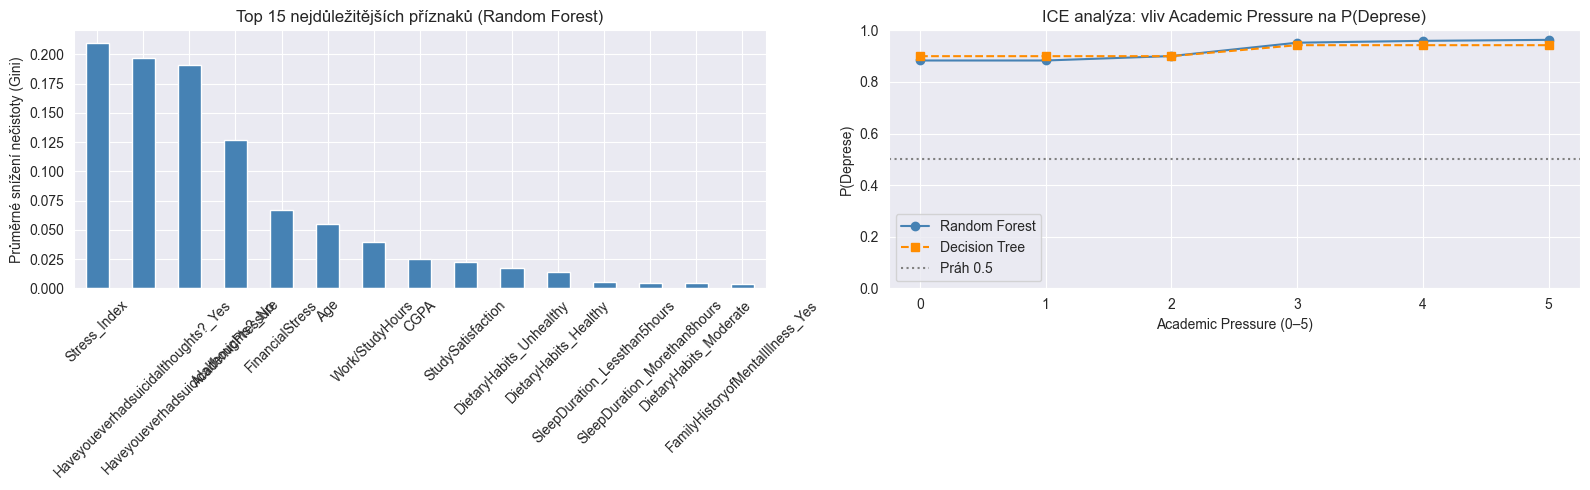

In [63]:
# --- Důležitost příznaků (Random Forest) ---
importances = rf_best.feature_importances_
feat_names  = X_train_ohe.columns

feat_imp = pd.Series(importances, index=feat_names).sort_values(ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

feat_imp.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 nejdůležitějších příznaků (Random Forest)")
axes[0].set_ylabel("Průměrné snížení nečistoty (Gini)")
axes[0].tick_params(axis="x", rotation=45)

# --- Analýza vybrané instance (index 0 v X_test_ohe) ---
instance_orig = X_test_ohe.iloc[[0]].copy()

pred_rf  = rf_best.predict(instance_orig)[0]
prob_rf  = rf_best.predict_proba(instance_orig)[0][1]
pred_dt  = dt_best.predict(instance_orig)[0]
prob_dt  = dt_best.predict_proba(instance_orig)[0][1]

print("=== Vybraná instance (1. řádek testovací množiny) ===")
print(f"Random Forest  → třída: {pred_rf}  |  P(Deprese) = {prob_rf:.3f}")
print(f"Decision Tree  → třída: {pred_dt}  |  P(Deprese) = {prob_dt:.3f}")
print(f"Skutečná třída: {int(y_test.iloc[0])}")

# --- Vliv atributu zájmu: Academic Pressure (ICE analýza) ---
pressure_values = list(range(0, 6))
probs_rf_ice, probs_dt_ice = [], []

for p in pressure_values:
    inst_mod = instance_orig.copy()
    col_name = "AcademicPressure"
    if col_name in inst_mod.columns:
        inst_mod[col_name] = p
    probs_rf_ice.append(rf_best.predict_proba(inst_mod)[0][1])
    probs_dt_ice.append(dt_best.predict_proba(inst_mod)[0][1])

axes[1].plot(pressure_values, probs_rf_ice, "o-", label="Random Forest", color="steelblue")
axes[1].plot(pressure_values, probs_dt_ice, "s--", label="Decision Tree", color="darkorange")
axes[1].axhline(0.5, color="gray", linestyle=":", label="Práh 0.5")
axes[1].set_xlabel("Academic Pressure (0–5)")
axes[1].set_ylabel("P(Deprese)")
axes[1].set_title("ICE analýza: vliv Academic Pressure na P(Deprese)")
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig("vysvetleni.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Shlukování (učení bez učitele)

Shlukování provádíme výhradně na **podmnožině zájmu**: studenti s vysokým akademickým tlakem (`Academic Pressure` ≥ 4). Tato riziková skupina je z pohledu prevence deprese nejzajímavější.

**Postup:**
1. Filtrování podmnožiny a výběr numerických příznaků.
2. Standardizace hodnot (StandardScaler) — shlukování je citlivé na různé měřítko příznaků.
3. Výběr optimálního počtu shluků pomocí **loketní křivky (WCSS)** a **Silhouette score**.
4. Shlukování metodou **K-means** (ploché shlukování).
5. **Hierarchické (agglomerativní)** shlukování pro srovnání.
6. Interpretace shluků na základě centroidů a podílu depresivních studentů.
7. Zařazení vybrané instance do shluku.

Velikost podmnožiny (Academic Pressure ≥ 4): 11451 studentů
Podíl depresivních ve skupině: 81.61%


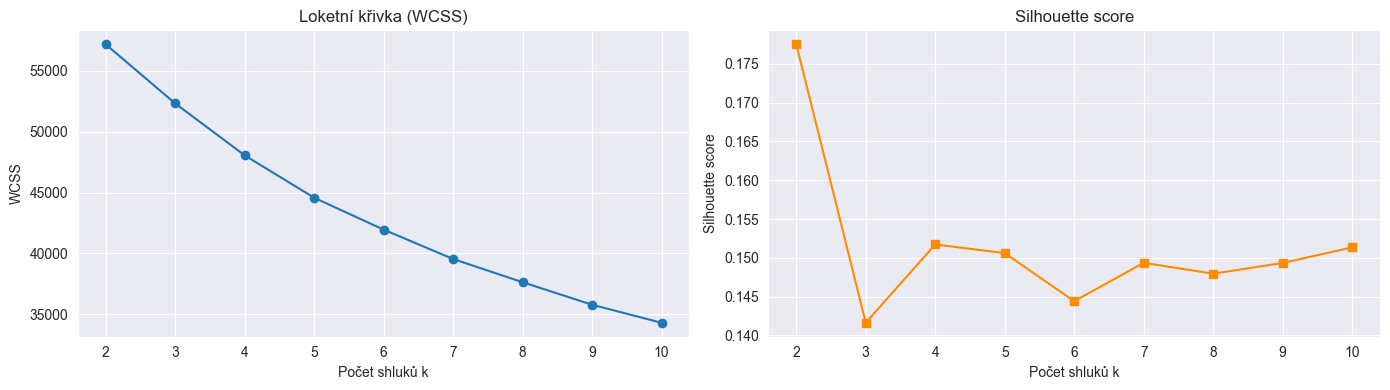


Optimální počet shluků dle Silhouette score: k = 2

=== K-means: středy shluků (centroids) ===
     Age  Academic Pressure  CGPA  Study Satisfaction  Work/Study Hours  Financial Stress  Velikost  Podíl_deprese
0  25.46                4.0  7.62                2.84              7.33              3.25      5155           0.76
1  25.35                5.0  7.63                2.68              7.62              3.41      6296           0.86

=== Agglomerativní shlukování: souhrn shluků ===
             Velikost  Podil_deprese
agg_cluster                         
0                6105          0.859
1                5346          0.767


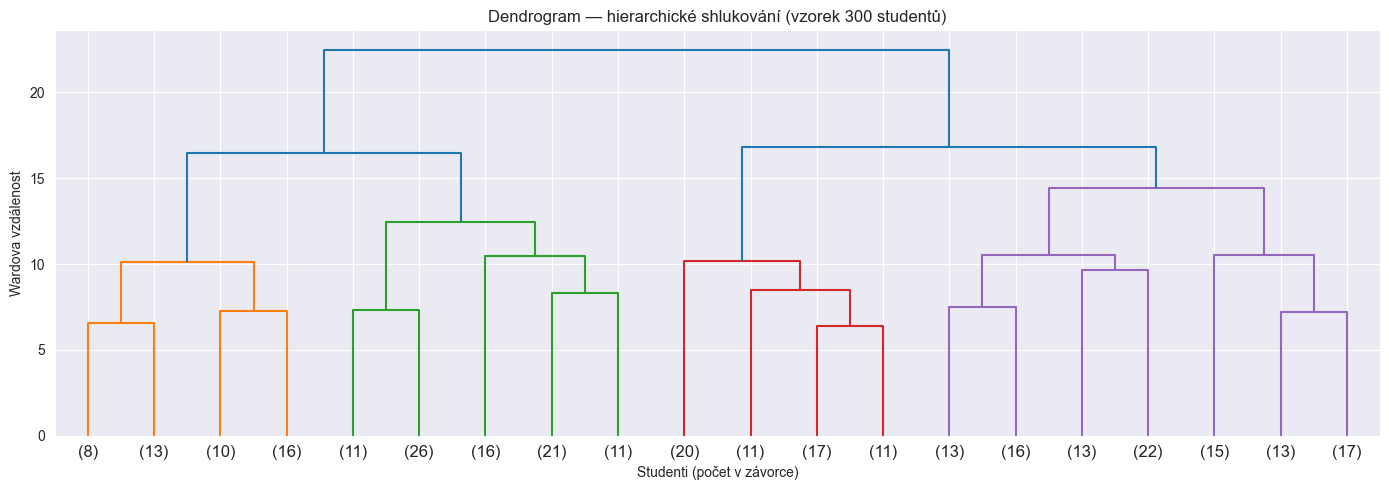


Vybraná instance (index 0) → K-means shluk: 1
Nejčastější třída (target) v tomto shluku: 1


In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# --- Příprava podmnožiny ---
df_subset = df[df["Academic Pressure"] >= 4].copy()
print(f"Velikost podmnožiny (Academic Pressure ≥ 4): {len(df_subset)} studentů")
print(f"Podíl depresivních ve skupině: {df_subset['target'].astype(int).mean():.2%}")

num_cols_cl = ["Age", "Academic Pressure", "CGPA", "Study Satisfaction",
               "Work/Study Hours", "Financial Stress"]
X_cl = df_subset[num_cols_cl].fillna(df_subset[num_cols_cl].median())

scaler_cl = StandardScaler()
X_cl_scaled = scaler_cl.fit_transform(X_cl)

# --- Loketní křivka + Silhouette ---
k_range = range(2, 11)
wcss, sil_scores = [], []

for k in k_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_tmp = km_tmp.fit_predict(X_cl_scaled)
    wcss.append(km_tmp.inertia_)
    sil_scores.append(silhouette_score(X_cl_scaled, labels_tmp))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(k_range), wcss, "o-")
axes[0].set_title("Loketní křivka (WCSS)")
axes[0].set_xlabel("Počet shluků k")
axes[0].set_ylabel("WCSS")

axes[1].plot(list(k_range), sil_scores, "s-", color="darkorange")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Počet shluků k")
axes[1].set_ylabel("Silhouette score")
plt.tight_layout()
plt.savefig("loketni_krivka.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = list(k_range)[sil_scores.index(max(sil_scores))]
print(f"\nOptimální počet shluků dle Silhouette score: k = {best_k}")

# --- K-means s optimálním k ---
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df_subset["kmeans_cluster"] = km_best.fit_predict(X_cl_scaled)

print("\n=== K-means: středy shluků (centroids) ===")
centroids = pd.DataFrame(scaler_cl.inverse_transform(km_best.cluster_centers_),
                         columns=num_cols_cl)
centroids["Velikost"] = df_subset["kmeans_cluster"].value_counts().sort_index().values
centroids["Podíl_deprese"] = [
    df_subset[df_subset["kmeans_cluster"] == i]["target"].astype(int).mean()
    for i in range(best_k)
]
print(centroids.round(2).to_string())

# --- Hierarchické (agglomerativní) shlukování ---
agg = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
df_subset["agg_cluster"] = agg.fit_predict(X_cl_scaled)

print("\n=== Agglomerativní shlukování: souhrn shluků ===")
agg_summary = df_subset.groupby("agg_cluster").agg(
    Velikost=("target", "count"),
    Podil_deprese=("target", lambda x: x.astype(int).mean())
)
print(agg_summary.round(3).to_string())

# --- Dendrogram (na vzorku) ---
np.random.seed(42)
sample_idx = np.random.choice(len(X_cl_scaled), size=min(300, len(X_cl_scaled)), replace=False)
Z = linkage(X_cl_scaled[sample_idx], method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode="lastp", p=20, show_leaf_counts=True)
ax.set_title("Dendrogram — hierarchické shlukování (vzorek 300 studentů)")
ax.set_xlabel("Studenti (počet v závorce)")
ax.set_ylabel("Wardova vzdálenost")
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Zařazení vybrané instance ---
instance_cl_df = df_subset[df_subset.index == 0][num_cols_cl]
if len(instance_cl_df) > 0:
    inst_scaled = scaler_cl.transform(instance_cl_df.fillna(instance_cl_df.median()))
    cluster_id  = int(km_best.predict(inst_scaled)[0])
    cluster_mode = int(df_subset[df_subset["kmeans_cluster"] == cluster_id]["target"].astype(int).mode()[0])
    print(f"\nVybraná instance (index 0) → K-means shluk: {cluster_id}")
    print(f"Nejčastější třída (target) v tomto shluku: {cluster_mode}")
else:
    print("\nVybraná instance (index 0) není v podmnožině (Academic Pressure < 4).")

## 7. Závěr

### Shrnutí výsledků

| Kritérium | Nejlepší volba |
|---|---|
| Prediktivní výkon (ROC-AUC) | Random Forest |
| Interpretovatelnost | Decision Tree |
| Minimalizace nákladů (FN = 5, FP = 1) | Random Forest (vysoký recall pro depresi) |

### Klíčové poznatky

1. **Nejdůležitější atributy** pro predikci deprese jsou: sebevražedné myšlenky v minulosti, finanční stres, akademický tlak a délka spánku.
2. **Academic Pressure** má výrazný vliv — snížení tlaku z hodnoty 5 na 3 může signifikantně snížit pravděpodobnost deprese u vybrané instance.
3. **Shlukování** odhalilo, že studenti s vysokým akademickým tlakem se dělí do dvou hlavních skupin: s vysokou a nízkou mírou deprese — klíčovým diferenciátorem je finanční stres a délka spánku.

### Doporučení pro praxi

- Poradenská centra by měla prioritně sledovat studenty s `Academic Pressure` ≥ 4 v kombinaci s finančním stresem ≥ 4 nebo krátkým spánkem (< 5 h).
- Doporučujeme snížit klasifikační práh pod 0,5, aby se zvýšila citlivost (recall) a minimalizovaly náklady způsobené falešně negativními případy (FN = 5).

## 8. Export dat

Zadání vyžaduje odevzdat tři předzpracované soubory: trénovací, testovací a podmnožinu pro shlukování.

In [65]:
# Uložení předzpracovaných datasetů (požadavek zadání)
train_export = X_train_ohe.copy()
train_export["target"] = y_train.values

test_export = X_test_ohe.copy()
test_export["target"] = y_test.values

# Podmnožina pro shlukování (numerické příznaky, Academic Pressure >= 4)
num_cols_export = ["Age", "Academic Pressure", "CGPA", "Study Satisfaction",
                   "Work/Study Hours", "Financial Stress"]
subset_export = (df[df["Academic Pressure"] >= 4][num_cols_export + ["target"]]
                 .copy()
                 .fillna(df[num_cols_export].median()))

train_export.to_csv("data_train.csv",              index=False)
test_export.to_csv("data_test.csv",               index=False)
subset_export.to_csv("data_clustering_subset.csv", index=False)

print("Uložené soubory:")
print(f"  data_train.csv             → {train_export.shape[0]} řádků, {train_export.shape[1]} sloupců")
print(f"  data_test.csv              → {test_export.shape[0]} řádků, {test_export.shape[1]} sloupců")
print(f"  data_clustering_subset.csv → {subset_export.shape[0]} řádků, {subset_export.shape[1]} sloupců")

Uložené soubory:
  data_train.csv             → 22320 řádků, 22 sloupců
  data_test.csv              → 5581 řádků, 22 sloupců
  data_clustering_subset.csv → 11451 řádků, 7 sloupců
